In [1]:
from pathlib import Path

import lasio 
import geopandas as gpd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
OUTPUT = ROOT / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)

In [3]:
# Utrecht boundaries
utrecht_city = gpd.read_file(PROCESSED / 'utrecht_city.gpkg')
utrecht_province = gpd.read_file(PROCESSED / 'utrecht_province.gpkg')

In [4]:
raw_data = pd.read_csv(PROCESSED / "target_lithologies_filled.csv")
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4035 entries, 0 to 4034
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                4035 non-null   str    
 1   easting                4035 non-null   float64
 2   northing               4035 non-null   float64
 3   depth_tvd_m            4035 non-null   float64
 4   porosity_pct           4035 non-null   float64
 5   gamma_ray_api          4035 non-null   float64
 6   bulk_density_gcc       4035 non-null   float64
 7   formation_thickness_m  4035 non-null   float64
 8   formation_top_tvd      4035 non-null   float64
 9   formation_base_tvd     4035 non-null   float64
dtypes: float64(9), str(1)
memory usage: 315.4 KB


In [5]:
df = raw_data.copy()
well_list = df["well_id"].unique().tolist()

### Temperature

In [6]:
dfs_las = {}

for well in well_list:
    las = lasio.read(RAW / f"{well}.las")
    
    df_las = las.df().reset_index()
    dfs_las[well] = df_las

    print(f"\n=========================================")
    print(f"Well Name: {well}")
    print(f"DataFrame Shape: {df_las.shape}")
    print(f"=========================================")
    
    print("--- HEADER METADATA ---")
    for item in las.well:
        print(f"{item.mnemonic:<10} | {item.descr:<40} : {item.value}")



Well Name: EVD-01
DataFrame Shape: (21569, 5)
--- HEADER METADATA ---
STRT       | First Index Value                        : 2196.9004
STOP       | Last Index Value                         : 40.1002
STEP       | Frame Spacing                            : -0.1
NULL       | Absent Value                             : -999.25
WELL       | Well Name                                : EVERDINGEN-01
FLD        | Field Name                               : UNKNOWN
CNTY       | County                                   : 
STAT       | State                                    : 
CTRY       | Country                                  : 
LOC        | Location                                 : 
API        | API Number                               : 
DATE       | Date                                     : 
COMP       | Company Name                             : NAM
SRVC       | Service Company                          : 

Well Name: PKP-01
DataFrame Shape: (27508, 6)
--- HEADER METADATA ---
STRT      

$$\text{Geothermal Gradient Model for Temperature}$$

$$ T(z) = T_s + G \cdot z $$

In [7]:
# Netherlands mean annual surface temperature
surface_temp_c = 10.0

# From BLT-01 Header Information
blt_bht = 167
blt_strt = 0
blt_tdl = 2123.8

# Fahrenheit to Celcius
blt_bht_c = (blt_bht - 32) / 1.8

gradient = (blt_bht_c - surface_temp_c) / (blt_tdl - blt_strt) 

df["temp_est_c"] = surface_temp_c + gradient * df["depth_tvd_m"]

gradients = {"BLT-01": gradient}
default_gradient = gradient

df["gradient_used"] = df["well_id"].map(gradients).fillna(default_gradient)
df["temp_est_c"] = surface_temp_c + df["gradient_used"] * df["depth_tvd_m"]

### Reservoir Quality

$$ RQI = w_{1}\phi + w_{2}h + w_{3}T - w_{4}GR - w_{5}D

In [8]:
# Aggregate of well into one spatial location
well_agg = df.groupby("well_id").agg(
    phi=("porosity_pct", "mean"),           
    h=("formation_thickness_m", "first"),  
    gr=("gamma_ray_api", "mean"),         
    t=("temp_est_c", "mean"),
    d=("depth_tvd_m", "mean"),
    easting=("easting", "first"),
    northing=("northing", "first"),
).reset_index()

# Normalization
phi_norm = (well_agg["phi"] - well_agg["phi"].min()) / (well_agg["phi"].max() - well_agg["phi"].min() + 1e-9)
h_norm   = (well_agg["h"]   - well_agg["h"].min())   / (well_agg["h"].max()   - well_agg["h"].min()   + 1e-9)
t_norm   = (well_agg["t"]   - well_agg["t"].min())   / (well_agg["t"].max()   - well_agg["t"].min()   + 1e-9)
gr_norm  = (well_agg["gr"]  - well_agg["gr"].min())  / (well_agg["gr"].max()  - well_agg["gr"].min()  + 1e-9)
d_norm   = (well_agg["d"]   - well_agg["d"].min())   / (well_agg["d"].max()   - well_agg["d"].min()   + 1e-9)

w1, w2, w3, w4, w5 = 0.35, 0.20, 0.15, 0.15, 0.15

well_agg["quality_score"] = (
    w1 * phi_norm
    + w2 * h_norm
    + w3 * t_norm
    - w4 * t_norm
    - w5 * d_norm
)

print(well_agg[["well_id", "easting", "northing", "phi", "h", "gr", "quality_score"]])

  well_id    easting   northing        phi           h         gr  \
0  BLT-01  141577.55  456881.76  16.376898  122.375449  48.996611   
1  EVD-01  136997.00  441189.00   9.122784   76.839000  28.501493   
2  JUT-01  134098.00  451726.00  12.574300  125.751900  24.318875   
3  PKP-01  118503.09  453402.51   9.041593   64.400332  64.993401   

   quality_score  
0       0.479806  
1       0.014768  
2       0.368561  
3      -0.150000  


In [9]:
well_agg["quality_rank"] = well_agg["quality_score"].rank(ascending=False).astype(int)
well_agg = well_agg.sort_values("quality_score", ascending=False)

def classify(score):
    if score < 5: return "poor"
    elif score < 10: return "marginal"
    elif score < 15: return "good"
    else: return "excellent"

well_agg["quality_class"] = well_agg["quality_score"].apply(classify)

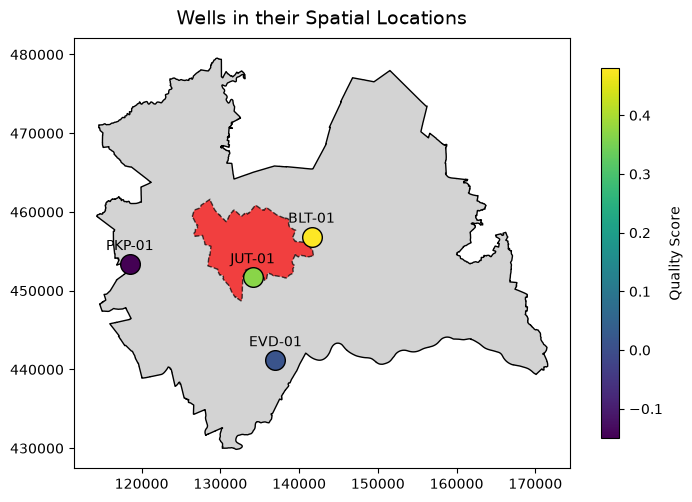

In [10]:
fig, ax = plt.subplots(figsize=(8, 8))

utrecht_province.plot(ax=ax, color="lightgrey", edgecolor='black')
utrecht_city.plot(ax=ax, color="red", edgecolor="black", linestyle="--", alpha=0.7)

for well in well_list:
    well_data = well_agg[well_agg['well_id'] == well]
    
    if not well_data.empty:
        x = well_data['easting'].values[0]
        y = well_data['northing'].values[0]
        score = well_data['quality_score'].values[0]
        
        sc = ax.scatter(x, y, c=[score], cmap='viridis', vmin=well_agg['quality_score'].min(), vmax=well_agg['quality_score'].max(), s=200, edgecolors='black', zorder=3)
        ax.annotate(well, (x, y), textcoords="offset points", xytext=(0,10), ha='center')

cbar = plt.colorbar(sc, ax=ax, shrink=0.6)
cbar.set_label('Quality Score')

ax.set_title("Wells in their Spatial Locations", fontsize=14, pad=10)
plt.show()
